## Instructions
* Read each cell and implement the **TODOs** sequentially. The markdown/text cells also contain instructions which you need to follow to get the whole notebook working.
* Do not change the variable names unless the instructor allows you to.
* Do not delete the **TODO** comment blocks.
* Aside from the TODOs, there will be questions embedded in the notebook and a cell for you to provide your answer (denoted with A:). Answer all the markdown/text cells with **"A: "** on them. 
* You are expected to search how to some functions work on the Internet or via the docs. 
* You may add new cells for "scrap work".
* The notebooks will undergo a "Restart and Run All" command, so make sure that your code is working properly.
* You are expected to understand the data set loading and processing separately from this class.
* You may not reproduce this notebook or share them to anyone.

Place your answers to the questions directly inline on the same cell as **A:**

For example:

<span style='color:red'>**Question 00:**</span> What is your favorite ice cream flavor?

<span style='color:red'>**A00:**</span> My favorite flavor ice cream flavor is pistachio.

# Assignment 2.3 - Robotics Notebook 
In this notebook, you will be experimenting on particle filtering and q-learning.

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import os
from robot.lidar import LiDAR
from robot.robot import Robot
from robot.pose import Pose3D

from environment.seg_environment import SegEnv
from environment.grid_map import GridMap
import drawing.drawing_functions_cv as drawing
import copy
import random

import imageio
import glob
from IPython import display

## Simple Particle Filtering for Robot Localization

The particle filter algorithm is a population based algorithm wherein we generate a bunch of initial guesses and slowly filter out the guesses that do not align with our observations. The next few sections will guide you in implementing particle filtering.

The code below defines a simulator for simulating a robot moving around a map. 

In [45]:
class Simulator:
    def __init__(self,robot, particles):
        self.robot = robot  # the simulated robot

        self.environment = SegEnv()  # the simulated environment
        self.environment.init_environment()

        self.grid_map = GridMap()  # the known grid map of the environment
        self.grid_map.init_map()
        self.grid_map.compute_map(self.environment)

        self.refresh_canvas()

        self.fig, self.ax = plt.subplots()
        self.particles = particles
        self.draw()
 
    def refresh_canvas(self):
        self.canvas = np.zeros((720, 720, 3)).astype(int)
    
    def draw(self, mode="canvas"):
        """ function to draw all the stuff"""
        self.refresh_canvas() 
        drawing.draw_grid_map(self.canvas, self.grid_map)

        drawing.draw_lidar_measurements(self.canvas, self.robot.get_measurements(self.environment), self.robot.pose, self.grid_map)
        drawing.draw_robot(self.canvas, self.robot, self.grid_map)

        drawing.draw_particles(self.canvas, self.particles, self.grid_map)

        self.draw_image()
        
    def draw_image(self):
        plt.imshow(self.canvas)
        plt.axis("off")

The code below initializes the simulator with a robot and 20 particles. 

The robot is visualized as a gray circle with a red arrow showing its pose. You will also see blue lines. These are visualizations of the LiDAR sensor. Each of the LiDAR sensor will return a distance measurement. However, if the distance is too big, then it will not be able to read a proper distance and will simply return -1. The line will also not be displayed in this case.

The particles are visualized as tiny dots with green arrows showing its pose. As you can see in the code, the particles are merely instances of the `Robot` class with randomly initialized pose. The difference is we treat them as guesses rather than the robot itself.

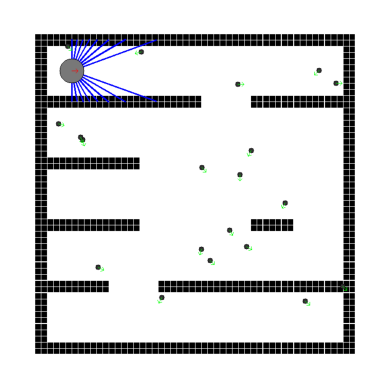

In [46]:
np.random.seed(0)
random.seed(0)
robot = Robot(pose= Pose3D(2, 2, 0),  sensor = LiDAR()) 
N = 20
particles = []
for i in range(N):
    particles.append(Robot(pose= Pose3D(np.random.uniform(1,11), np.random.uniform(1,11), np.random.randint(0,12) * np.pi / 12),  sensor = LiDAR()))

sim = Simulator(robot=robot, particles = particles)

The robot can get measurements of its surroundings using the `get_measurements` method. It accepts the environment as its parameter. The measurements it returns is in a form of a dictionary where the keys are the lidar sensors at different angles, and the values are the distance measurements.

In [47]:
sim.robot.get_measurements(sim.environment)

{-90: 1.0240411933229856,
 -80: 1.0001157859570087,
 -70: 1.0721424308788479,
 -60: 1.1346640532077374,
 -50: 1.2994376618514218,
 -40: 1.5707606356852317,
 -30: 2.012214364130767,
 -20: 2.9147931986591344,
 -10: -1,
 0: -1,
 10: -1,
 20: 2.919267412861842,
 30: 2.0008023304241065,
 40: 1.5431427938831677,
 50: 1.3109294893828887,
 60: 1.1769763112999536,
 70: 1.0506253575403997,
 80: 0.995611281090212,
 90: 1.0028824374558107}

Before we implement the particle filter, we should first define the function that computes the probability of a measurement given the true robot measurements. For convenience, we assume that this probability follows a normal distribution with the mean given by the true robot measurement and the variance $\sigma^2$ is the sensor noise. 

For each of the lidar measurement, we use the following formula to compute the probability:
$$P(x_\text{particle} | x_\text{robot}) = \frac{1}{\sigma\sqrt{2\pi}} e^{-\frac{1}{2} \left( \frac{(x_\text{particle} - x_\text{robot})^2}{\sigma^2} \right) } $$
To compute the probability of measurements over all angles, we compute the product of the individual sensor probabilites.

In [48]:
############################################################
# TODO-01: Implement the function that computes the        #
# measurement probability of the particles with respect to #
# the true robot measurements.                             #
############################################################

def compute_measurement_prob(self, robot_measurements, particle_measurements, sensor_noise_sigma=1):
    probabilities = []
    for particle_measurement in particle_measurements:
        try:
            # Convert dictionary values to numpy arrays for computation
            robot_array = np.array(list(robot_measurements.values()))
            particle_array = np.array(list(particle_measurement.values()))
            
            # Calculate the difference between robot and particle measurements
            diff = robot_array - particle_array
            
            # Compute likelihood assuming Gaussian noise
            likelihood = np.exp(-0.5 * np.sum((diff / sensor_noise_sigma)**2)) / (sensor_noise_sigma * np.sqrt(2 * np.pi))
            probabilities.append(likelihood)
        except Exception:
            probabilities.append(0)  # Assign a default probability in case of error
    return probabilities

############################################################
#                    End of your code.                     #
############################################################



Let's extend the simulator class and implement a particle filter iteration.

In [49]:
def particle_filter_iteration(self, motion):
    # Move the robot based on the motion command
    if motion == "forward":
        self.robot.move_up()
    elif motion == "left":
        self.robot.move_left()
    elif motion == "right":
        self.robot.move_right()

    # Get new measurements from the environment
    robot_measurements = self.robot.get_measurements(self.environment)

    particle_measurements = []

    ############################################################
    # TODO-02: Loop through all the particles (stored in       #
    # self.particles). Move them in the same way as the robot  #
    # and get the measurement reading. Collect all of the      #
    # measurements into the list named particle_measurements.  #
    ############################################################
    for particle in self.particles:
        try:
            if motion == "forward":
                particle.move_up()
            elif motion == "left":
                particle.move_left()
            elif motion == "right":
                particle.move_right()
            particle_measurements.append(particle.get_measurements(self.environment))
        except Exception:
            particle_measurements.append({})

    ############################################################
    # TODO-03: Compute the probability of each of the particle #
    # measurement with respect to the true robot               #
    # measurement readings. You will want to use the           #
    # implemented function self.compute_measurement_prob.      #
    # Store these probabilities in the list called             #
    # particle_measurement_probs.                              #
    ############################################################
    particle_measurement_probs = self.compute_measurement_prob(
        robot_measurements, particle_measurements
    )
    particle_measurement_probs = np.array(particle_measurement_probs)

    ###############################################################
    # TODO-04: Normalize the list of measurement probabilities to #
    # ensure that they sum to 1.                                  #
    ###############################################################
    if np.sum(particle_measurement_probs) == 0:
        raise ValueError("Sum of measurement probabilities is zero. Unable to normalize.")
    particle_measurement_probs /= np.sum(particle_measurement_probs)

    ############################################################
    # TODO-05: Next step is to resample the particles with     #
    # replacement based on their measurement probabilities and #
    # store them into the list named resampled_particles. Look #
    # up the function np.random.choice to do this. Note that   #
    # we want to create new copies of the particles and not    #
    # resample the same instance. Therefore, you will need to  #
    # use the function copy.deepcopy(). This is important      #
    # because if you return the same instance, then there      #
    # could be multiple repeated actions for the same          #
    # particle.                                                #
    ############################################################
    resampled_particles = np.random.choice(
        self.particles, 
        size=len(self.particles), 
        replace=True, 
        p=particle_measurement_probs
    )
    resampled_particles = [copy.deepcopy(particle) for particle in resampled_particles]

    # Update particles
    self.particles = resampled_particles


Simulator.compute_measurement_prob = compute_measurement_prob
Simulator.particle_filter_iteration = particle_filter_iteration

The code below will perform the particle filter iterations and create a gif visualizing the particle filtering process.

In [ ]:
np.random.seed(0)
random.seed(0)
output_folder = "motion_gif"

robot = Robot(pose= Pose3D(2, 2, 0),  sensor = LiDAR()) 
N = 5000
particles = []
for i in range(N):
    particles.append(Robot(pose= Pose3D(np.random.uniform(1,11), np.random.uniform(1,11), np.random.randint(0,12) * np.pi / 12),  sensor = LiDAR()))

sim = Simulator(robot=robot, particles = particles)

sim.draw(mode="rgb")
plt.savefig("{}/{:03d}.png".format(output_folder, 0),dpi=150, bbox_inches="tight")

motion_list = ["forward", "forward", "forward", "left", "left", "left","right","right", "forward", "forward", "forward", "forward","right","right","right", "forward", "forward"]

os.makedirs(output_folder, exist_ok=True)
for i,motion in enumerate(motion_list):
    sim.particle_filter_iteration(motion=motion)
    sim.draw(mode="rgb")
    plt.savefig("{}/{:03d}.png".format(output_folder, i+1),dpi=150, bbox_inches="tight")
plt.close()
gif_images = sorted(glob.glob("{}/*.png".format(output_folder)))
particle_filter_gif = [imageio.v3.imread(frame) for frame in gif_images]
imageio.mimsave("{}/particle_filter.gif".format(output_folder), particle_filter_gif, format='GIF', fps=1, loop=0)
with open("{}/particle_filter.gif".format(output_folder),"rb") as f:
    display.display(display.Image(data=f.read(), format='png'))

<span style='color:red'>**Question 01:**</span> During the particle filter iterations, you will notice that there are clusters of points at the bottom of the map and also a around the robot. Explain why they are not filtered out and remain for several iterations. 

<span style='color:red'>**A01:**</span>

<span style='color:red'>**Question 02:**</span> Is particle filter sensitive to the initialization of the particles? Why or why not?

<span style='color:red'>**A02:**</span>

# Reinforcement Learning Crawler environment

The next part will guide you in implementing a simple q-learning reinforcement learning algorithm that can learn to move a robot arm in order to make the robot crawl forward.

You would need to firt install gymnasium (https://github.com/Farama-Foundation/Gymnasium).

In [ ]:
import gymnasium as gym
import numpy as np
from crawler_env import KTAICrawlerEnv
np.set_printoptions(precision=3)
import time

Let's run the crawler environment with a random policy. You will see the random controller can sometimes make progress but it won't get very far. 

In [ ]:
env = KTAICrawlerEnv(
    render=True, # turn render mode on to visualize random motion
)

# standard procedure for interfacing with a Gym environment
cur_state = env.reset() # reset environment and get initial state
ret = 0.
done = False
i = 0
while not done:
    action = env.action_space.sample() # sample an action randomly
    next_state, reward, done, info = env.step(action)
    ret += reward
    cur_state = next_state
    time.sleep(0.01)
    i += 1
    if i == 1500:
        break # for the purpose of this visualization, let's only run for 1500 steps
        # also note the GUI won't close automatically

In [ ]:
# you can close the visualization GUI with the following method 
env.close_gui()

In [ ]:
env = KTAICrawlerEnv()

print("We can inspect the observation space and action space of this Gymnasium Environment")
print("-----------------------------------------------------------------------------")
print("Action space:", env.action_space)
print("It's a discrete space with %i actions to take" % env.action_space.n)
print("Each action corresponds to increasing/decreasing the angle of one of the joints")
print("We can also sample from this action space:", env.action_space.sample())
print("Another action sample:", env.action_space.sample())
print("Another action sample:", env.action_space.sample())
print("Observation space:", env.observation_space, ", which means it's a 9x13 grid.")
print("It's the discretized version of the robot's two joint angles")

We can inspect the observation space and action space of this Gymnasium Environment
-----------------------------------------------------------------------------
Action space: Discrete(4)
It's a discrete space with 4 actions to take
Each action corresponds to increasing/decreasing the angle of one of the joints
We can also sample from this action space: 1
Another action sample: 1
Another action sample: 1
Observation space: Tuple(Discrete(9), Discrete(13)) , which means it's a 9x13 grid.
It's the discretized version of the robot's two joint angles


Let's implement Tabular Q-Learning with $\epsilon$-greedy exploration to find a better policy piece by piece.


In [ ]:
from collections import defaultdict
import random

# dictionary that maps from state, s, to a numpy array of Q values [Q(s, a_1), Q(s, a_2) ... Q(s, a_n)]
#   and everything is initialized to 0.
q_vals = defaultdict(lambda: np.array([0. for _ in range(env.action_space.n)]))

print("Q-values for state (0, 0): %s" % q_vals[(0, 0)], "which is a list of Q values for each action")
print("As such, the Q value of taking action 3 in state (1,2), i.e. Q((1,2), 3), can be accessed by q_vals[(1,2)][3]:", q_vals[(1,2)][3])

Q-values for state (0, 0): [0. 0. 0. 0.] which is a list of Q values for each action
As such, the Q value of taking action 3 in state (1,2), i.e. Q((1,2), 3), can be accessed by q_vals[(1,2)][3]: 0.0


In [ ]:
def eps_greedy(q_vals, eps, state):
    """
    Inputs:
        q_vals: q value tables
        eps: epsilon
        state: current state
    Outputs:
        random action with probability of eps; argmax Q(s, .) with probability of (1-eps)
    """
    # you might want to use random.random() to implement random exploration
    #   number of actions can be read off from len(q_vals[state])
    
    ###############################################################
    # TODO-06: Implement Epsilon Greedy exploration for choosing  #
    # an action.                                                  #
    ###############################################################

    # Random exploration with probability eps
    if random.random() < eps:
        return random.randint(0, len(q_vals[state]) - 1)
    # Exploit the best known action
    else:
        return np.argmax(q_vals[state])

    ############################################################
    #                    End of your code.                     #
    ############################################################

The code below tests the implementation of the epsilon greedy function.

In [ ]:

# test 1
dummy_q = defaultdict(lambda: np.array([0. for _ in range(env.action_space.n)]))
test_state = (0, 0)
dummy_q[test_state][0] = 10.
trials = 100000
sampled_actions = [
    int(eps_greedy(dummy_q, 0.3, test_state))
    for _ in range(trials)
]
freq = np.sum(np.array(sampled_actions) == 0) / trials
tgt_freq = 0.3 / env.action_space.n + 0.7
if np.isclose(freq, tgt_freq, atol=1e-2):
    print("Test1 passed")
else:
    print("Test1: Expected to select 0 with frequency %.2f but got %.2f" % (tgt_freq, freq))
    
# test 2
dummy_q = defaultdict(lambda: np.array([0. for _ in range(env.action_space.n)]))
test_state = (0, 0)
dummy_q[test_state][2] = 10.
trials = 100000
sampled_actions = [
    int(eps_greedy(dummy_q, 0.5, test_state))
    for _ in range(trials)
]
freq = np.sum(np.array(sampled_actions) == 2) / trials
tgt_freq = 0.5 / env.action_space.n + 0.5
if np.isclose(freq, tgt_freq, atol=1e-2):
    print("Test2 passed")
else:
    print("Test2: Expected to select 2 with frequency %.2f but got %.2f" % (tgt_freq, freq))

Test1 passed
Test2 passed


Next we will implement Q learning update. After we observe a transition $s, a, s', r$,

$$\textrm{target}(s') = R(s,a,s') + \gamma \max_{a'} Q_{\theta_k}(s',a')$$


$$Q_{k+1}(s,a) \leftarrow (1-\alpha) Q_k(s,a) + \alpha \left[ \textrm{target}(s') \right]$$

In [ ]:
def q_learning_update(gamma, alpha, q_vals, cur_state, action, next_state, reward):
    """
    Inputs:
        gamma: discount factor
        alpha: learning rate
        q_vals: q value table
        cur_state: current state
        action: action taken in current state
        next_state: next state results from taking `action` in `cur_state`
        reward: reward received from this transition
    
    Performs in-place update of q_vals table to implement one step of Q-learning
    """
    ###############################################################
    # TODO-07: Implement an in-place q learning update.           #
    ###############################################################

    # Extract current Q-value for (state, action)
    current_q = q_vals[cur_state][action]
    # Compute the maximum Q-value for the next state
    max_next_q = np.max(q_vals[next_state])
    # Apply the Q-learning update rule
    q_vals[cur_state][action] = current_q + alpha * (reward + gamma * max_next_q - current_q)


    ###############################################################
    #                    End of your code.                        #
    ###############################################################

The code below tests the implementation of the q-learning update.

In [ ]:
# testing your q_learning_update implementation
dummy_q = q_vals.copy()
test_state = (0, 0)
test_next_state = (0, 1)
dummy_q[test_state][0] = 10.
dummy_q[test_next_state][1] = 10.
q_learning_update(0.9, 0.1, dummy_q, test_state, 0, test_next_state, 1.1)
tgt = 10.01
if np.isclose(dummy_q[test_state][0], tgt,):
    print("Test passed")
else:
    print("Q(test_state, 0) is expected to be %.2f but got %.2f" % (tgt, dummy_q[test_state][0]))

Test passed


In [ ]:
def greedy_eval():
    """evaluate greedy policy w.r.t current q_vals"""
    test_env = KTAICrawlerEnv(horizon=np.inf)
    
    ret = 0.
    done = False
    H = 100
    
    prev_state = test_env.reset()
    for i in range(H):
        
        ###############################################################
        # TODO-08: Implement a greedy policy, that is, always choose  #
        # the action with the highest q values.                       #
        ###############################################################
        
        ###############################################################
        # Hint: Look at the code on how to run the random policy      #
        # at the beginning of this notebook.                          #
        ###############################################################

        ###############################################################
        # Step 1: determine the action based on the q values at       #
        # the current state.                                          #
        ###############################################################
        
        ###############################################################
        # Step 2: take the action and get the next state, rewards.    #
        ###############################################################

        action = np.argmax(q_vals[prev_state])  # Greedy policy
        
        next_state, reward, done, info = test_env.step(action)




        
        ###############################################################
        #                    End of your code.                        #
        ###############################################################
        
        
        ret += reward
        prev_state = next_state
    return ret / H

In [ ]:
# now with the main components tested, we can put everything together to create a complete q learning agent

env = KTAICrawlerEnv() 
# initialize q_values to 0
q_vals = defaultdict(lambda: np.array([0. for _ in range(env.action_space.n)]))
# gamma discount factor
gamma = 0.9
# alpha learning rate
alpha = 0.1
# epsilon greedy exploration parameter
eps = 0.5


cur_state = env.reset()
for itr in range(300000):
    ###############################################################
    # TODO-09: use epsilon greedy actions and perform q learning  #
    # update                                                      #
    ###############################################################

    # Step 1: Choose an action using epsilon-greedy policy
    action = eps_greedy(q_vals, eps, cur_state)
    
    # Step 2: Take the action, observe the next state and reward
    next_state, reward, done, info = env.step(action)
    
    # Step 3: Perform Q-learning update
    q_learning_update(gamma, alpha, q_vals, cur_state, action, next_state, reward)
    
    # Step 4: Update the current state
    cur_state = next_state
    
    ###############################################################
    #                    End of your code.                        #
    ###############################################################

    if itr % 50000 == 0: # evaluation with greedy evaluation
        print("Itr %i # Average speed: %.2f" % (itr, greedy_eval()))

# at the end of learning your crawler should reach a speed of >= 3

Itr 0 # Average speed: 0.05
Itr 50000 # Average speed: 2.03
Itr 100000 # Average speed: 3.37
Itr 150000 # Average speed: 3.37
Itr 200000 # Average speed: 3.37
Itr 250000 # Average speed: 3.37


After the learning is successful, we can visualize the learned robot controller. Remember we learn this just from interacting with the environment instead of peeking into the dynamics model!

In [ ]:
env = KTAICrawlerEnv(render=True, horizon=500)
prev_state = env.reset()
ret = 0.
done = False
while not done:
    action = np.argmax(q_vals[prev_state])
    state, reward, done, info = env.step(action)
    ret += reward
    prev_state = state
    time.sleep(0.01)

In [ ]:
# you can close the visualization GUI with the following method 
env.close_gui()

<span style='color:red'>**TODO-10:**</span> Plot the performance of the q-learning model as a function of the hyperparameter settings. You can add as many cells as necessary.

<span style='color:red'>**Question:**</span> How much time did it take you to answer this notebook?

<span style='color:red'>**A:**</span>

<span style='color:red'>**Question:**</span> What parts of the assignment did you like and what parts did you not like?

<span style='color:red'>**A:**</span>

<span style='color:red'>**Question:**</span> How do you think it could be improved?

<span style='color:red'>**A:**</span>

<span style='color:red'>**Question:**</span> Do you have any case studies in mind that would be nice to suggest / include in the assignment?

<span style='color:red'>**A:**</span>

Credits to Remy Guyonneau for the simulator and to Pieter Abbeel, Yan Duan, and Xi Chen for the crawler environment.